In [28]:
import os
import numpy as np
import kagglehub
import librosa
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [29]:
SAMPLE_RATE = 16000 # częstotliwość próbkowania audio 16 kHz
N_MFCC = 13 # liczba współczynników MFCC do wyodrębnienia z sygnału audio
N_MELS = 64 # liczba filtrów Mel do zastosowania w transformacji Mel-spectrogramu
MAX_SAMPLES = 160000 # maksymalna liczba próbek do przetworzenia (10 sekund przy 16 kHz)
SEED = 42 # wartość ziarna losowego dla powtarzalności wyników

np.random.seed(SEED) # ustawienie ziarna losowego dla NumPy
tf.random.set_seed(SEED) # ustawienie ziarna losowego dla TensorFlow

In [30]:
print("POBIERANIE ZBIORU DANYCH")

path = kagglehub.dataset_download("bryandarquea/psg-audio-apnea-audios")
psg_path = os.path.join(path, "PSG-AUDIO")

# dzielenie plików na dwie listy: z apneą i bez apneą na podstawie końcówek nazw plików ("_ap.npy" dla apneą i "_nap.npy" dla braku apneą)
apnea_files = []
no_apnea_files = []

for root, dirs, files in os.walk(psg_path):
    for f in files:
        if f.endswith("_ap.npy"):
            apnea_files.append(os.path.join(root, f))
        elif f.endswith("_nap.npy"):
            no_apnea_files.append(os.path.join(root, f))

print(f"\nPliki z apneą: {len(apnea_files)}")
print(f"Pliki bez apneą: {len(no_apnea_files)}")

POBIERANIE ZBIORU DANYCH

Pliki z apneą: 192
Pliki bez apneą: 191


In [ ]:
def extract_features_safe(audio, sr=SAMPLE_RATE):
    """
    Wyodrębnia cechy, unikając NaN/Inf
    """
    features = []

    try:
      # 1) MFCC (librosa.feature.mfcc + NumPy):
        # Wyznacza współczynniki MFCC opisujące kształt widma w skali mel, czyli „barwę” i strukturę oddechu.
        # Następnie liczymy mean/std (np.nanmean, np.nanstd), aby dostać stałowymiarowy, odporny na długość sygnału opis.
        # To podstawowe cechy do wykrywania wzorców oddechowych związanych z epizodami bezdechu.

        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
        mfcc_mean = np.nanmean(mfcc, axis=1)
        mfcc_std = np.nanstd(mfcc, axis=1)
        features.extend(mfcc_mean)
        features.extend(mfcc_std)
    except Exception as e:
        print(f"Error MFCC: {e}")
        features.extend([0.0] * (N_MFCC * 2))

    try:
       # 2) Mel-spectrogram (librosa.feature.melspectrogram + librosa.power_to_db + NumPy):
        # Tworzy reprezentację czas-częstotliwość w skali mel, zbliżoną do percepcji słuchowej człowieka.
        # Konwersja do dB (power_to_db) stabilizuje zakres wartości i ułatwia uczenie modelu.
        # Mean/std po osiach czasu dają zwięzły wektor energii pasmowej użyteczny w klasyfikacji apnea/non-apnea.
        
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        mel_mean = np.nanmean(mel_spec_db, axis=1)
        mel_std = np.nanstd(mel_spec_db, axis=1)
        features.extend(mel_mean)
        features.extend(mel_std)
    except Exception as e:
        print(f"Error Mel Spec: {e}")
        features.extend([0.0] * (N_MELS * 2))

    try:
        # 3) Zero Crossing Rate (librosa.feature.zero_crossing_rate + NumPy):
         # ZCR mierzy częstość zmian znaku sygnału (przejść przez zero), czyli prosty wskaźnik „szorstkości”/aktywności.
         # Mean/std streszczają dynamikę sygnału i pomagają odróżniać spokojny oddech od fragmentów zakłóconych.
         # To lekka obliczeniowo cecha uzupełniająca MFCC i mel-spectrogram.
        
        zcr = librosa.feature.zero_crossing_rate(audio)
        zcr_mean = np.nanmean(zcr)
        zcr_std = np.nanstd(zcr)
        features.extend([zcr_mean, zcr_std])
    except Exception as e:
        print(f"Error ZCR: {e}")
        features.extend([0.0, 0.0])

    try:
        # 4) Spectral Centroid (librosa.feature.spectral_centroid + NumPy):
         # Spectral centroid opisuje „środek ciężkości” widma, czyli gdzie koncentruje się energia częstotliwości.
         # Mean/std pokazują, czy sygnał jest bardziej nisko- czy wysokoczęstotliwościowy oraz jak to się zmienia.
         # Cecha wspiera model w rozróżnianiu różnych charakterystyk akustycznych oddychania.
        
        spec_cent = librosa.feature.spectral_centroid(y=audio, sr=sr)
        spec_cent_mean = np.nanmean(spec_cent)
        spec_cent_std = np.nanstd(spec_cent)
        features.extend([spec_cent_mean, spec_cent_std])
    except Exception as e:
        print(f"Error Spec Centroid: {e}")
        features.extend([0.0, 0.0])

    try:
        # 5) RMS Energy (librosa.feature.rms + NumPy):
         # RMS opisuje energię/głośność sygnału w czasie i pomaga uchwycić spadki/wzrosty amplitudy oddechu.
         # Mean/std agregują poziom i zmienność energii do postaci zgodnej z wejściem modelu.
         # To ważne dla wykrywania epizodów o obniżonej aktywności oddechowej.
        
        rms = librosa.feature.rms(y=audio)
        rms_mean = np.nanmean(rms)
        rms_std = np.nanstd(rms)
        features.extend([rms_mean, rms_std])
    except Exception as e:
        print(f"Error RMS: {e}")
        features.extend([0.0, 0.0])

    # Oczyszczenie wartości końcowych
    features = np.array(features, dtype=np.float32)
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)

    return features


def process_file(filepath, label):
    """
    Przetwarza plik .npy wyodrębniając cechy ze wszystkich podsygnałów
    """
    try:
        data = np.load(filepath)

        if data.ndim != 2:
            print(f"{filepath}: Dimensión inesperada {data.ndim}")
            return None, None

        n_samples, sample_len = data.shape

        # Przetwarzanie wszystkich podsygnałów
        all_features = []

        for i in range(n_samples):
            audio = data[i, :MAX_SAMPLES]

            # Padding jeśli to konieczne
            if len(audio) < MAX_SAMPLES:
                audio = np.pad(audio, (0, MAX_SAMPLES - len(audio)), mode='constant')

            features = extract_features_safe(audio)
            all_features.append(features)

        all_features = np.array(all_features)
        labels = np.full(len(all_features), label)

        return all_features, labels

    except Exception as e:
        print(f"Błąd podczas przetwarzania {filepath}: {e}")
        return None, None

In [32]:
print("WYODRĘBNIANIE CECH")

X_data = []
y_data = []

print("\nPrzetwarzanie plików Z apneą")
for i, filepath in enumerate(tqdm(apnea_files)):
    features, labels = process_file(filepath, label=1)
    if features is not None:
        X_data.append(features)
        y_data.append(labels)

print("\nPrzetwarzanie plików BEZ apneą")
for i, filepath in enumerate(tqdm(no_apnea_files)):
    features, labels = process_file(filepath, label=0)
    if features is not None:
        X_data.append(features)
        y_data.append(labels)

# Połączenie wszystkiego
X = np.vstack(X_data)
y = np.hstack(y_data)

print(f"\nDatos totales: {X.shape[0]} muestras")
print(f"Shape de features: {X.shape}")
print(f"Distribución de clases: {np.bincount(y)}")
print(f"Características extraídas: {X.shape[1]}")

WYODRĘBNIANIE CECH

Przetwarzanie plików Z apneą


100%|██████████| 192/192 [11:43<00:00,  3.67s/it]



Przetwarzanie plików BEZ apneą


100%|██████████| 191/191 [07:05<00:00,  2.23s/it]


Datos totales: 103210 muestras
Shape de features: (103210, 160)
Distribución de clases: [38625 64585]
Características extraídas: 160


In [33]:
print("\nNormalizacja cech")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Sprawdzenie czy nie ma NaN po normalizacji
if np.isnan(X_scaled).any():
    print("Znaleziono NaN po normalizacji, oczyszczanie")
    X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Datos normalizados - Shape: {X_scaled.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"\nZbiór treningowy: {X_train.shape[0]} próbek")
print(f"Zbiór testowy: {X_test.shape[0]} próbek")


Normalizacja cech
Datos normalizados - Shape: (103210, 160)

Zbiór treningowy: 82568 próbek
Zbiór testowy: 20642 próbek


In [34]:
print("BUDOWANIE MODELU")

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC()]
)

print(model.summary())

BUDOWANIE MODELU


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,273 (337.00 KB)

 Trainable params: 85,377 (333.50 KB)

 Non-trainable params: 896 (3.50 KB)

None


In [35]:
print("TRENOWANIE MODELU")

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

model.save('model_apnea.keras')

TRENOWANIE MODELU
Epoch 1/200
2065/2065 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step - accuracy: 0.6769 - auc_2: 0.6862 - loss: 0.6110 - val_accuracy: 0.7332 - val_auc_2: 0.7743 - val_loss: 0.5420
Epoch 2/200
2065/2065 ━━━━━━━━━━━━━━━━━━━━ 2s 771us/step - accuracy: 0.7190 - auc_2: 0.7566 - loss: 0.5583 - val_accuracy: 0.7517 - val_auc_2: 0.8077 - val_loss: 0.5118
Epoch 3/200
2065/2065 ━━━━━━━━━━━━━━━━━━━━ 2s 808us/step - accuracy: 0.7332 - auc_2: 0.7830 - loss: 0.5347 - val_accuracy: 0.7597 - val_auc_2: 0.8245 - val_loss: 0.4911
Epoch 4/200
2065/2065 ━━━━━━━━━━━━━━━━━━━━ 2s 775us/step - accuracy: 0.7446 - auc_2: 0.7981 - loss: 0.5188 - val_accuracy: 0.7711 - val_auc_2: 0.8306 - val_loss: 0.4817
Epoch 5/200
2065/2065 ━━━━━━━━━━━━━━━━━━━━ 2s 772us/step - accuracy: 0.7514 - auc_2: 0.8100 - loss: 0.5057 - val_accuracy: 0.7779 - val_auc_2: 0.8467 - val_loss: 0.4659
Epoch 6/200
2065/2065 ━━━━━━━━━━━━━━━━━━━━ 2s 794us/step - accuracy: 0.7590 - auc_2: 0.8193 - loss: 0.4952 - val_accuracy: 0.7780 - val_a

In [36]:
print("OCENA MODELU")

y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

print("\nRaport Klasyfikacji:")
print(classification_report(y_test, y_pred, target_names=['No Apnea', 'Apnea']))

print("\nMacierz pomyłek:")
print(confusion_matrix(y_test, y_pred))

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {auc_score:.4f}")

OCENA MODELU
646/646 ━━━━━━━━━━━━━━━━━━━━ 0s 298us/step

Raport Klasyfikacji:
              precision    recall  f1-score   support

    No Apnea       0.84      0.77      0.80      7725
       Apnea       0.87      0.92      0.89     12917

    accuracy                           0.86     20642
   macro avg       0.86      0.84      0.85     20642
weighted avg       0.86      0.86      0.86     20642


Macierz pomyłek:
[[ 5918  1807]
 [ 1093 11824]]

ROC-AUC Score: 0.9337


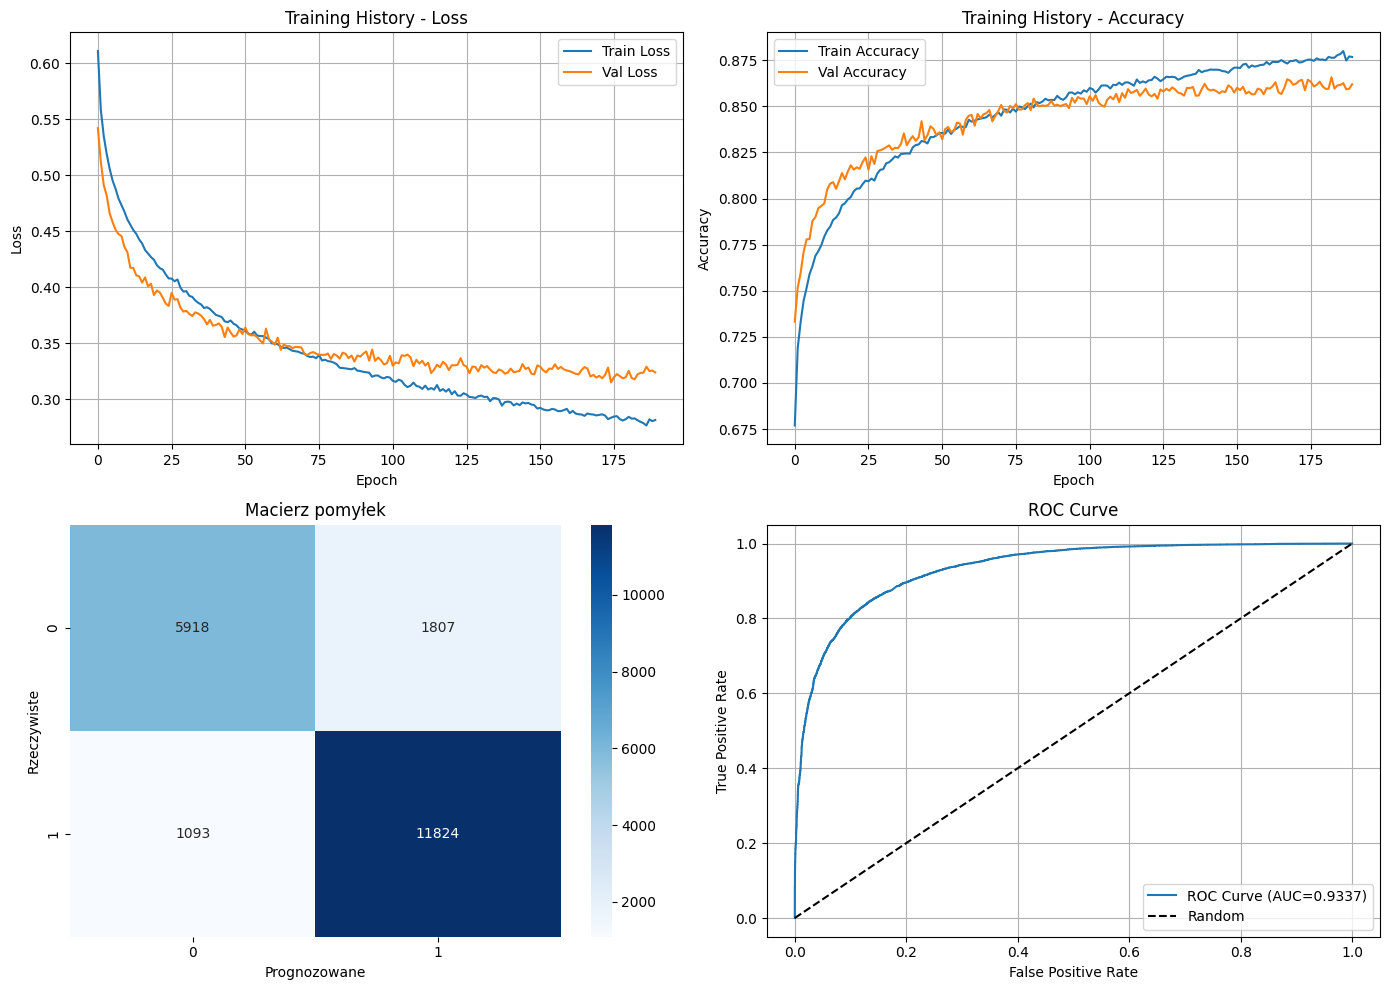

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Historia treningowa
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training History - Loss')
axes[0, 0].legend()
axes[0, 0].grid()

# Dokładność
axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training History - Accuracy')
axes[0, 1].legend()
axes[0, 1].grid()

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Macierz pomyłek')
axes[1, 0].set_xlabel('Prognozowane')
axes[1, 0].set_ylabel('Rzeczywiste')

# Krzywa ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1, 1].plot(fpr, tpr, label=f'ROC Curve (AUC={auc_score:.4f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curve')
axes[1, 1].legend()
axes[1, 1].grid()

plt.tight_layout()
plt.savefig('apnea_detection_results.png', dpi=150, bbox_inches='tight')
plt.show()


Ładowanie modelu...
Wykonywanie prognoz...

Generowanie wizualizacji...
Wykres zapisany: prediction_examples.png


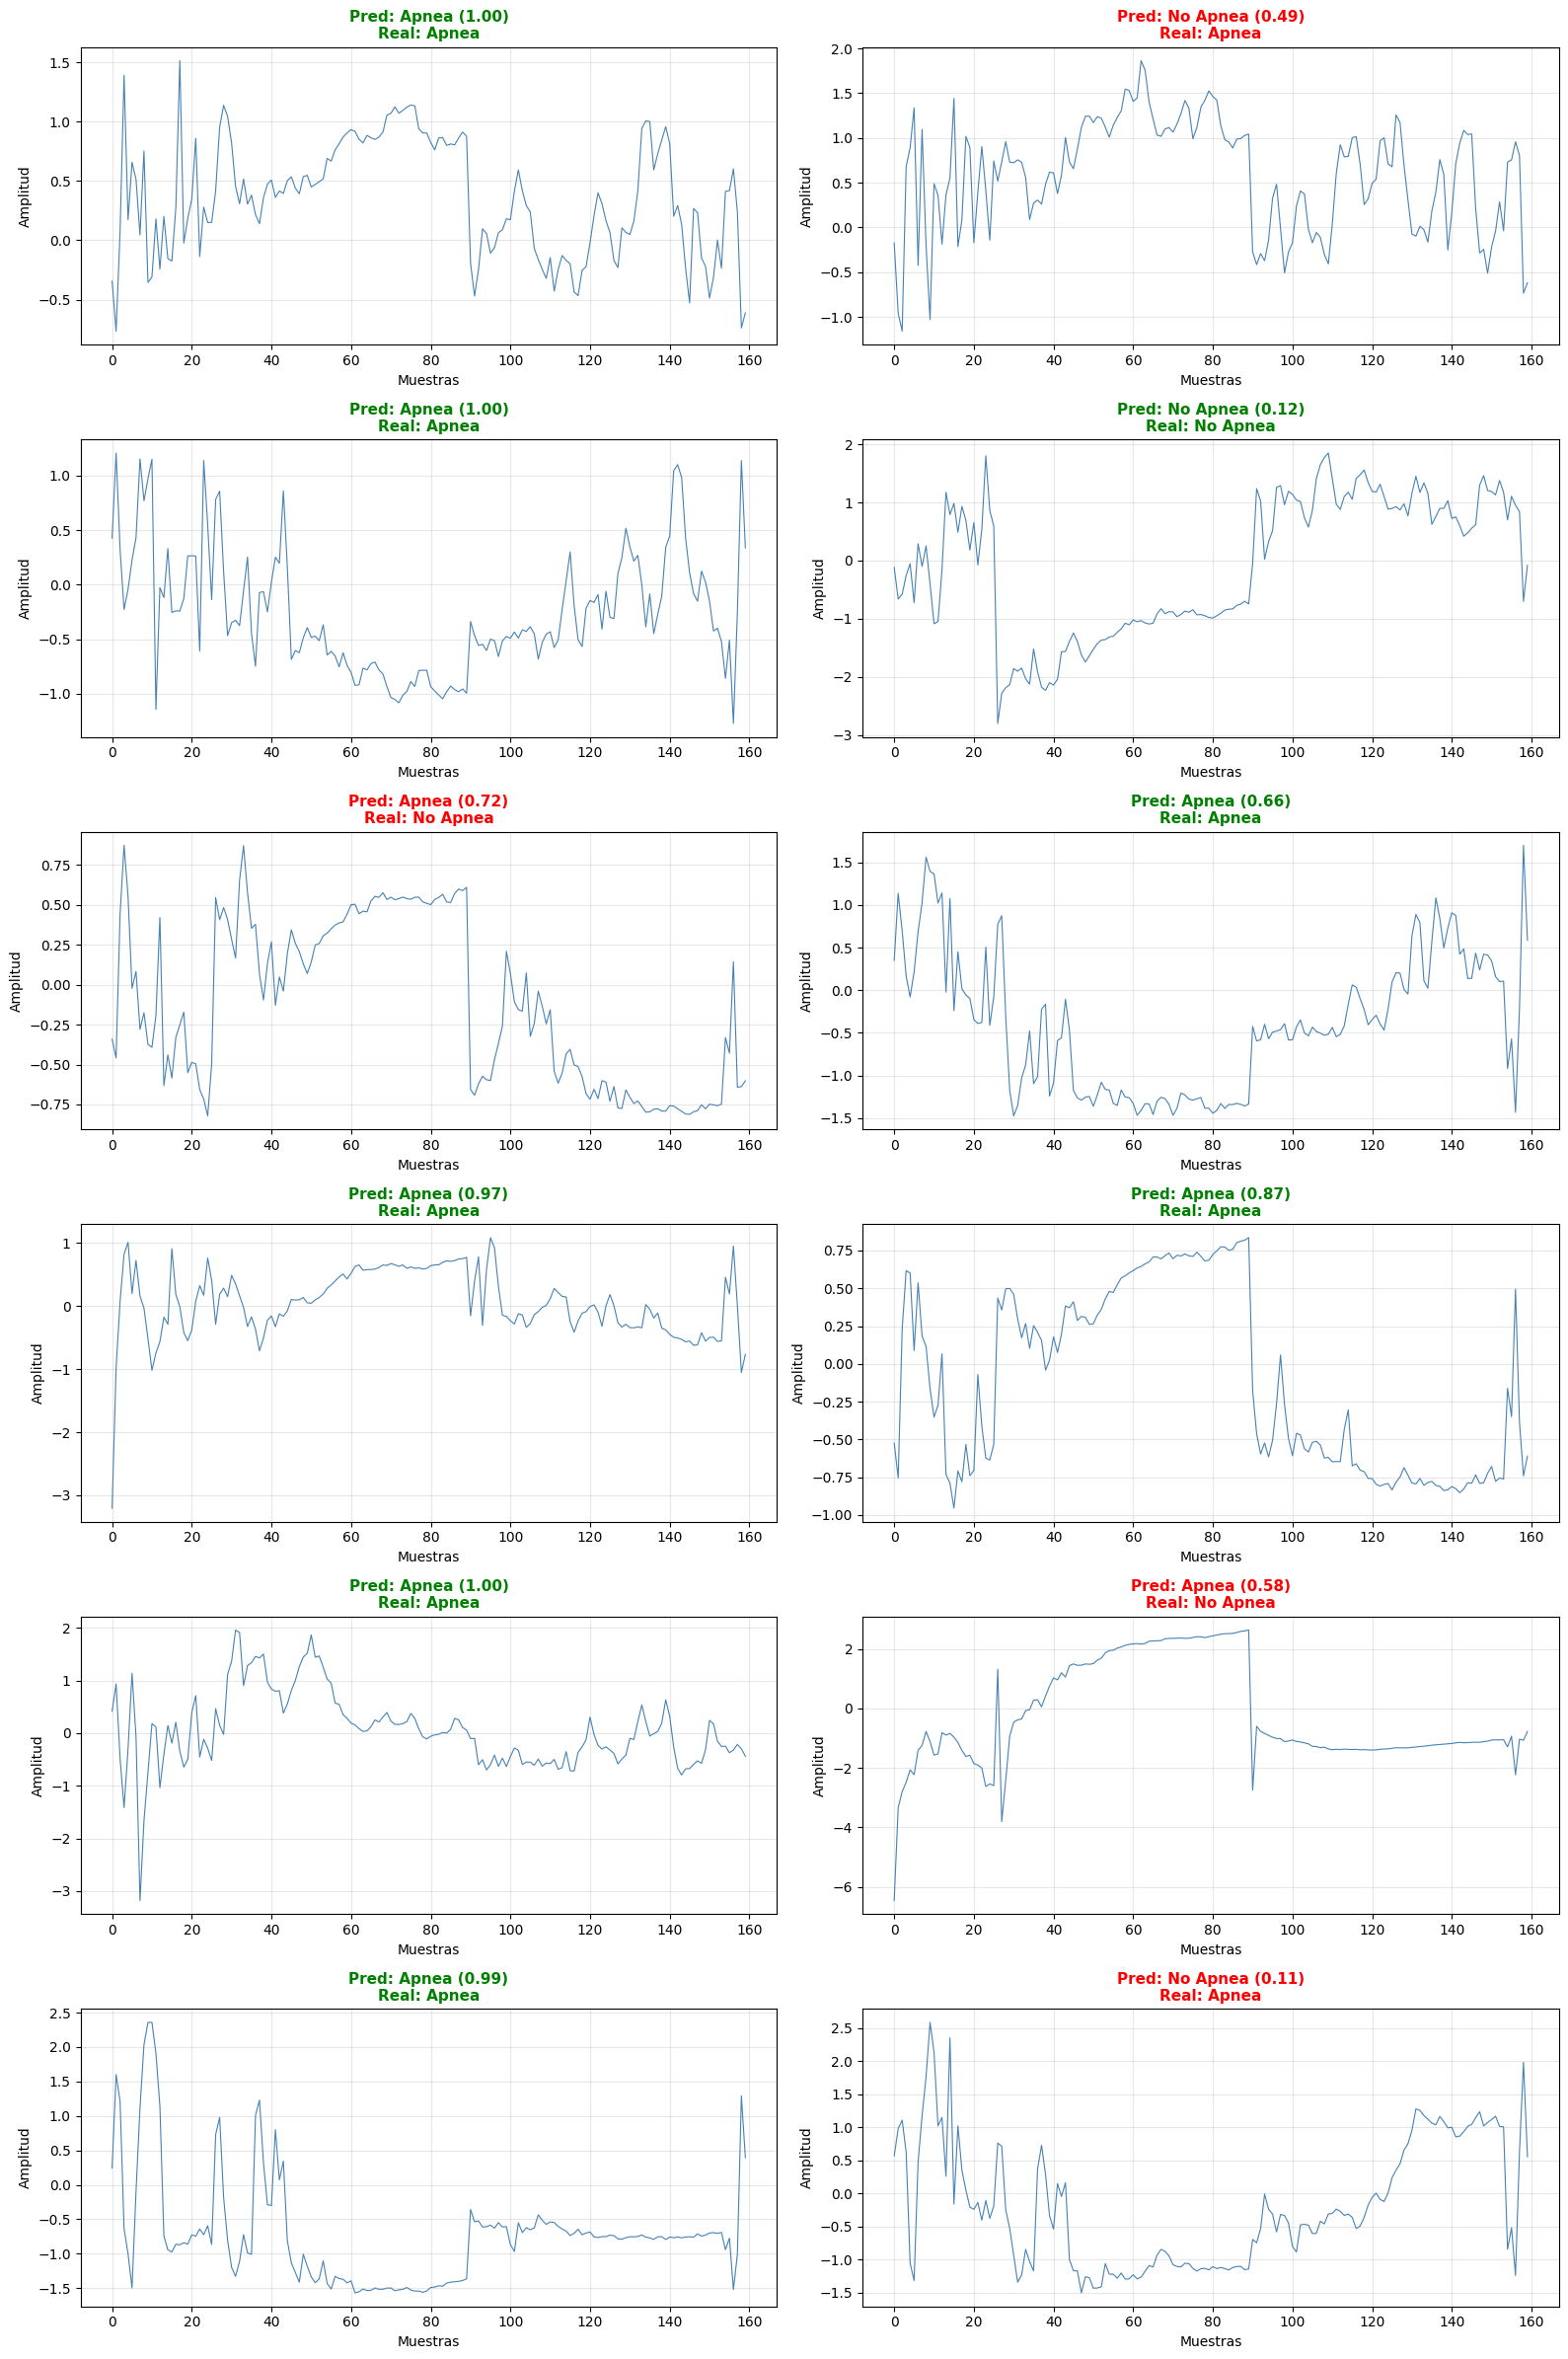

/var/folders/7d/sp9sn8k14bj4kqjm8zqzlp_h0000gn/T/ipykernel_66525/3868472917.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


Wykres zapisany: prediction_statistics.png


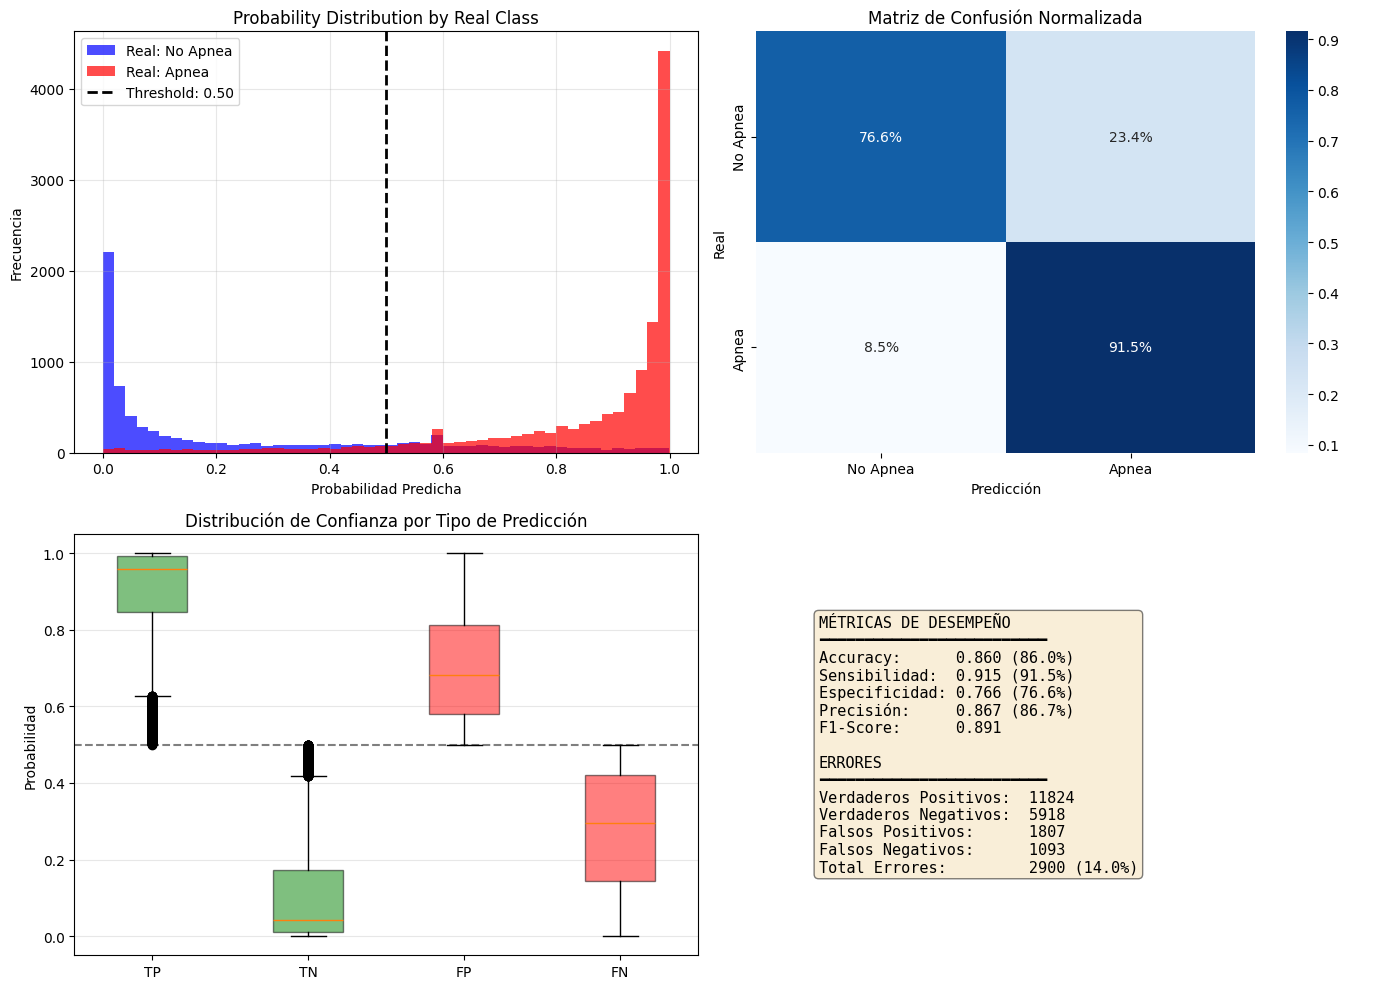


Raport Klasyfikacji:
              precision    recall  f1-score   support

    No Apnea       0.84      0.77      0.80      7725
       Apnea       0.87      0.92      0.89     12917

    accuracy                           0.86     20642
   macro avg       0.86      0.84      0.85     20642
weighted avg       0.86      0.86      0.86     20642



In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import seaborn as sns

def preprocess_signal(x, max_len=160000):
    """Wstępne przetwarzanie pojedynczego sygnału"""
    if np.std(x) < 1e-6:
        return None
    x = (x - np.mean(x)) / (np.std(x) + 1e-8)
    x = np.clip(x, -10, 10)
    if len(x) > max_len:
        start = np.random.randint(0, len(x) - max_len)
        x = x[start:start + max_len]
    else:
        x = np.pad(x, (0, max_len - len(x)))
    return x

def visualize_predictions(model, X_test, y_test, y_pred_prob, y_pred,
                          optimal_threshold=0.5, num_samples=12,
                          signal_length=10000, save_path="prediction_examples.png"):
    """Wizualizacja prognoz z poprawnymi i niepoprawnym przykładami"""
    correct_mask = y_pred == y_test
    incorrect_mask = y_pred != y_test

    correct_indices = np.where(correct_mask)[0]
    incorrect_indices = np.where(incorrect_mask)[0]

    num_incorrect = min(num_samples // 3, len(incorrect_indices))
    num_correct = num_samples - num_incorrect

    if len(incorrect_indices) > 0:
        selected_incorrect = np.random.choice(incorrect_indices, num_incorrect, replace=False)
    else:
        selected_incorrect = np.array([])

    selected_correct = np.random.choice(correct_indices, num_correct, replace=False)
    selected_indices = np.concatenate([selected_incorrect, selected_correct])
    np.random.shuffle(selected_indices)

    cols = 2
    rows = (len(selected_indices) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()

    for plot_idx, test_idx in enumerate(selected_indices):
        ax = axes[plot_idx]
        signal = X_test[test_idx].flatten()[:signal_length]

        pred_prob = y_pred_prob[test_idx]
        pred_label = y_pred[test_idx]
        real_label = y_test[test_idx]

        is_correct = pred_label == real_label
        color = 'green' if is_correct else 'red'
        pred_text = 'Apnea' if pred_label == 1 else 'No Apnea'
        real_text = 'Apnea' if real_label == 1 else 'No Apnea'

        ax.plot(signal, linewidth=0.8, color='steelblue')
        title = f"Pred: {pred_text} ({pred_prob:.2f})\nReal: {real_text}"
        ax.set_title(title, fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Muestras')
        ax.set_ylabel('Amplitud')
        ax.grid(True, alpha=0.3)

    for idx in range(len(selected_indices), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Wykres zapisany: {save_path}")
    plt.show()

def plot_prediction_statistics(y_test, y_pred, y_pred_prob, optimal_threshold=0.5):
    """Wizualizacja statystyk prognoz"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    ax.hist(y_pred_prob[y_test == 0], bins=50, alpha=0.7, label='Real: No Apnea', color='blue')
    ax.hist(y_pred_prob[y_test == 1], bins=50, alpha=0.7, label='Real: Apnea', color='red')
    ax.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold: {optimal_threshold:.2f}')
    ax.set_xlabel('Probabilidad Predicha')
    ax.set_ylabel('Frecuencia')
    ax.set_title('Probability Distribution by Real Class')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', ax=ax,
                xticklabels=['No Apnea', 'Apnea'],
                yticklabels=['No Apnea', 'Apnea'])
    ax.set_title('Matriz de Confusión Normalizada')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

    ax = axes[1, 0]
    tp_idx = (y_pred == 1) & (y_test == 1)
    tn_idx = (y_pred == 0) & (y_test == 0)
    fp_idx = (y_pred == 1) & (y_test == 0)
    fn_idx = (y_pred == 0) & (y_test == 1)

    data_to_plot = [y_pred_prob[tp_idx], y_pred_prob[tn_idx],
                    y_pred_prob[fp_idx], y_pred_prob[fn_idx]]
    labels = ['TP', 'TN', 'FP', 'FN']
    colors = ['green', 'green', 'red', 'red']

    bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    ax.set_ylabel('Probabilidad')
    ax.set_title('Distribución de Confianza por Tipo de Predicción')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(optimal_threshold, color='black', linestyle='--', alpha=0.5)

    ax = axes[1, 1]
    ax.axis('off')

    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity + 1e-8)

    stats_text = f"""MÉTRICAS DE DESEMPEÑO
━━━━━━━━━━━━━━━━━━━━━━━━━
Accuracy:      {accuracy:.3f} ({accuracy*100:.1f}%)
Sensibilidad:  {sensitivity:.3f} ({sensitivity*100:.1f}%)
Especificidad: {specificity:.3f} ({specificity*100:.1f}%)
Precisión:     {precision:.3f} ({precision*100:.1f}%)
F1-Score:      {f1:.3f}

ERRORES
━━━━━━━━━━━━━━━━━━━━━━━━━
Verdaderos Positivos:  {tp}
Verdaderos Negativos:  {tn}
Falsos Positivos:      {fp}
Falsos Negativos:      {fn}
Total Errores:         {fp + fn} ({(fp+fn)/(tp+tn+fp+fn)*100:.1f}%)"""

    ax.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
            verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig("prediction_statistics.png", dpi=150, bbox_inches='tight')
    print("Wykres zapisany: prediction_statistics.png")
    plt.show()

if __name__ == "__main__":
    print("\nŁadowanie modelu...")
    model = tf.keras.models.load_model('model_apnea.keras')

    print("Wykonywanie prognoz...")
    y_pred_prob = model.predict(X_test, verbose=0).flatten()
    optimal_threshold = 0.5
    y_pred = (y_pred_prob > optimal_threshold).astype(int)

    print("\nGenerowanie wizualizacji...")
    visualize_predictions(model, X_test, y_test, y_pred_prob, y_pred,
                         optimal_threshold=optimal_threshold, num_samples=12)
    plot_prediction_statistics(y_test, y_pred, y_pred_prob, optimal_threshold)

    print("\nRaport Klasyfikacji:")
    print(classification_report(y_test, y_pred,
                               target_names=['No Apnea', 'Apnea']))